In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Essential libraries for data handling and visualization
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for image processing and deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input

# Set matplotlib style
sns.set_style('whitegrid')

# Set random seed for reproducibility
import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

print("Libraries imported and warnings ignored successfully!")

Libraries imported and warnings ignored successfully!


In [ ]:
# Download latest version of the dataset
path = kagglehub.dataset_download("gpiosenka/car-parts-40-classes")
print("Path to dataset files:", path)

# Check folder structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:5]:  # show first 5 files per directory
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files)")

# Paths
train_path = os.path.join(path, "train")
valid_path = os.path.join(path, "valid")
test_path  = os.path.join(path, "test")

Path to dataset files: /kaggle/input/car-parts-40-classes
car-parts-40-classes/
    car parts 50/
        EfficientNetB0-50-(224 X 224)- 97.99.h5
        car parts.csv
        valid/
            CARBERATOR/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
            SIDE MIRROR/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
            AIR COMPRESSOR/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
            TRANSMISSION/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
            BRAKE PAD/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
            GAS CAP/
                5.jpg
                1.jpg
                4.jpg
                3.jpg
                2.jpg
          

In [ ]:
data_path = r'/kaggle/input/car-parts-40-classes/car parts 50'
trainpath = os.path.join(data_path, 'train')
validpath = os.path.join(data_path, 'valid')
testpath  = os.path.join(data_path, 'test')

In [ ]:
# Helper function: build dataframe
def build_dataframe(path, name, limiter=None):
    classes = os.listdir(path)
    filepaths, labels = [], []

    for klass in classes:
        classpath = os.path.join(path, klass)
        flist = os.listdir(classpath)

        # Apply limiter if specified
        if limiter is not None and len(flist) > limiter:
            flist = np.random.choice(flist, limiter, replace=False)

        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)

    df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})
    return df

# Build train/valid/test DataFrames
train_df = build_dataframe(trainpath, 'train')
valid_df = build_dataframe(validpath, 'valid')
test_df  = build_dataframe(testpath, 'test')

In [ ]:
# Overview
print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")
print(f"Test set size: {len(test_df)}")
print(f"\nNumber of classes: {train_df['labels'].nunique()}")

Train set size: 8739
Validation set size: 250
Test set size: 250

Number of classes: 50


In [ ]:
# Class distribution in train set
train_counts = train_df['labels'].value_counts()
print("\nTraining set class distribution (Top 10):")
print(train_counts.head(10))


Training set class distribution (Top 10):
labels
IGNITION COIL    200
IDLER ARM        198
STARTER          195
CARBERATOR       192
ALTERNATOR       190
RADIO            189
OVERFLOW TANK    189
SHIFT KNOB       189
FUEL INJECTOR    188
BRAKE PAD        188
Name: count, dtype: int64


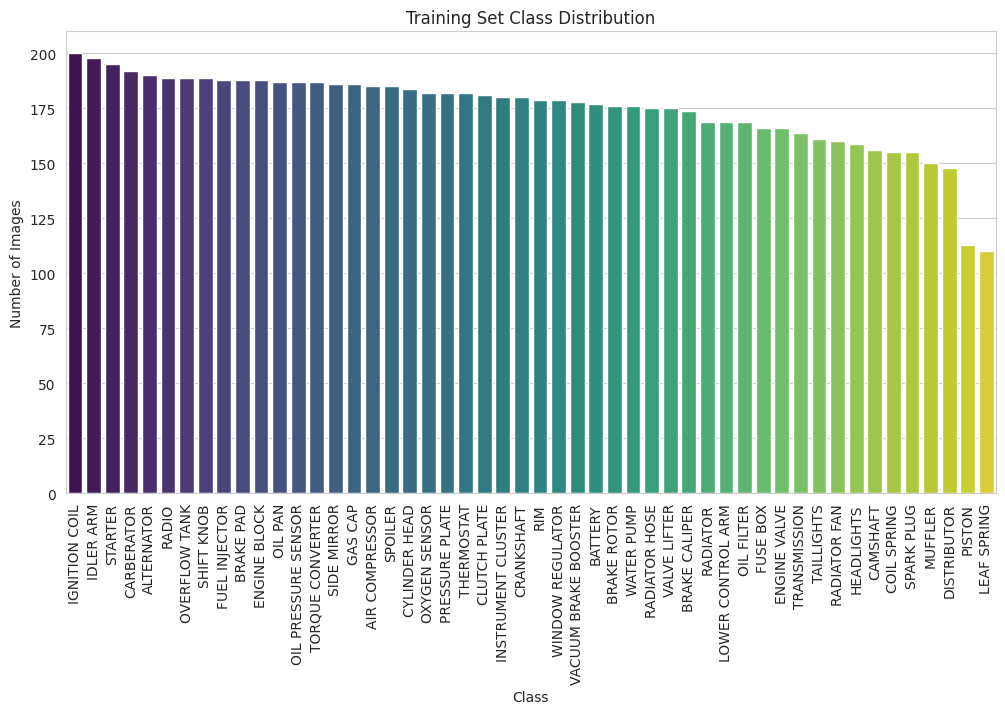

In [ ]:
# Plot class distribution
plt.figure(figsize=(12,6))
sns.barplot(x=train_counts.index, y=train_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
import cv2
import random

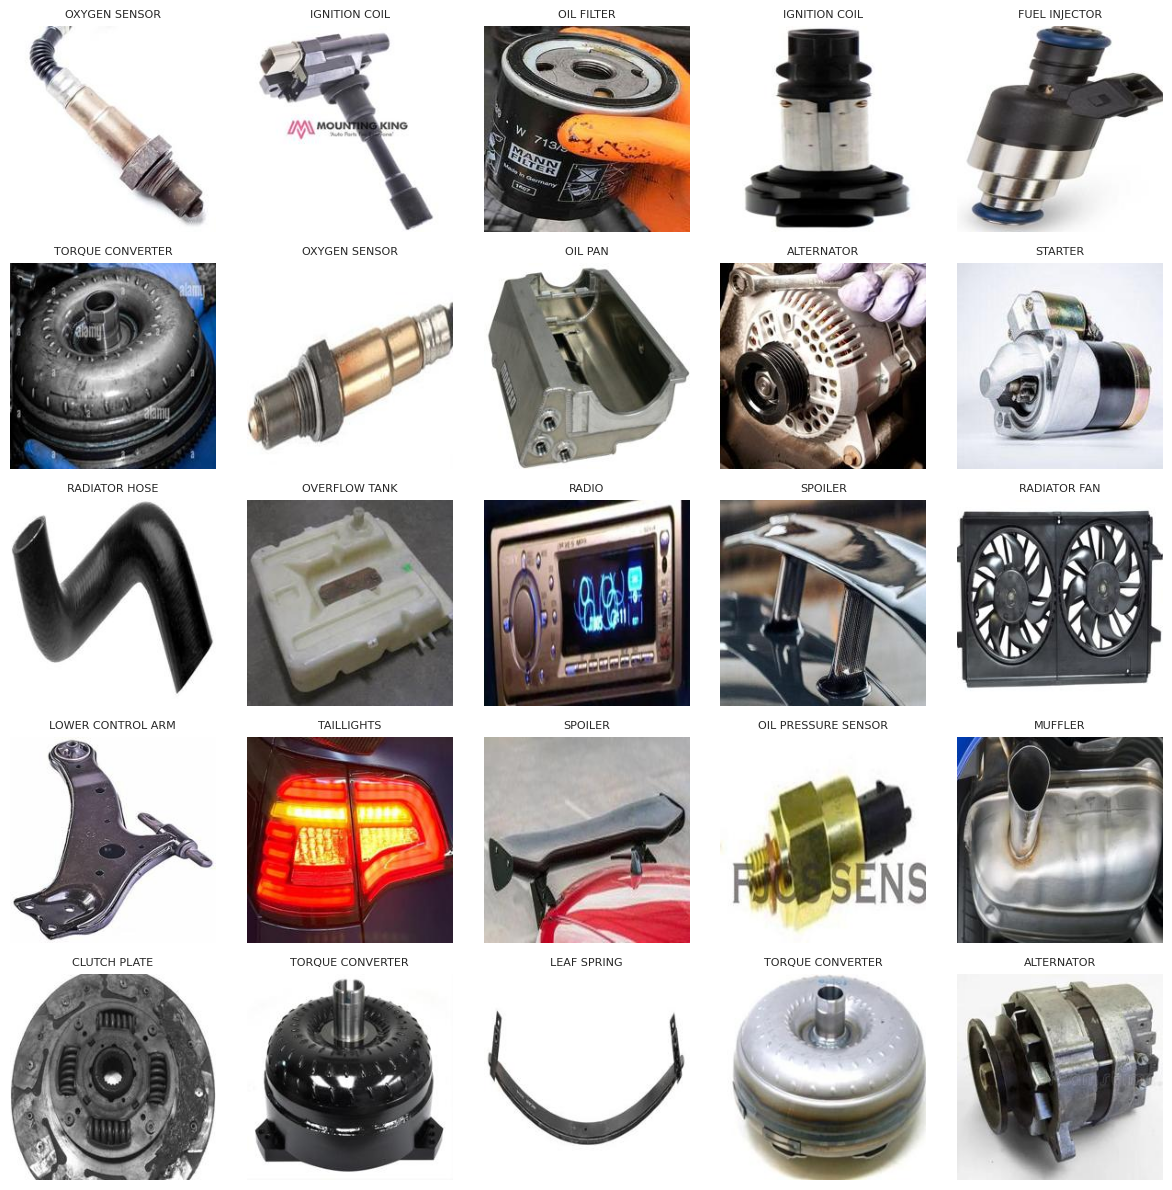

In [ ]:
# Sample Images Grid
def show_samples(df, n=25):
    plt.figure(figsize=(12,12))
    samples = df.sample(n)
    for i, (filepath, label) in enumerate(zip(samples['filepaths'], samples['labels'])):
        img = cv2.imread(filepath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(5,5,i+1)
        plt.imshow(img)
        plt.title(label, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_df, n=25)

In [ ]:
# Image Dimension Check
dims = []
for fp in train_df['filepaths'].sample(200):  # check 200 random images
    img = cv2.imread(fp)
    if img is not None:
        dims.append(img.shape)

dims = pd.DataFrame(dims, columns=["Height","Width","Channels"])
print("\nImage Dimension Summary:")
print(dims.describe())


Image Dimension Summary:
       Height  Width  Channels
count   200.0  200.0     200.0
mean    224.0  224.0       3.0
std       0.0    0.0       0.0
min     224.0  224.0       3.0
25%     224.0  224.0       3.0
50%     224.0  224.0       3.0
75%     224.0  224.0       3.0
max     224.0  224.0       3.0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset directories
data_path = "/kaggle/input/car-parts-40-classes/car parts 50"
train_dir = os.path.join(data_path, "train")
valid_dir = os.path.join(data_path, "valid")
test_dir  = os.path.join(data_path, "test")

# Parameters
target_size = (224, 224)
batch_size = 32

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 8739 images belonging to 50 classes.
Found 250 images belonging to 50 classes.
Found 250 images belonging to 50 classes.


In [ ]:
# Handle Class Imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9447567567567567), 1: np.float64(0.9198947368421052), 2: np.float64(0.987457627118644), 3: np.float64(1.0044827586206897), 4: np.float64(0.9296808510638298), 5: np.float64(0.9930681818181818), 6: np.float64(1.1203846153846153), 7: np.float64(0.9103125), 8: np.float64(0.965635359116022), 9: np.float64(1.1276129032258064), 10: np.float64(0.971), 11: np.float64(0.9498913043478261), 12: np.float64(1.180945945945946), 13: np.float64(0.9296808510638298), 14: np.float64(1.0528915662650602), 15: np.float64(0.9296808510638298), 16: np.float64(1.0528915662650602), 17: np.float64(0.9396774193548387), 18: np.float64(1.099245283018868), 19: np.float64(0.8827272727272727), 20: np.float64(0.8739), 21: np.float64(0.971), 22: np.float64(1.5889090909090908), 23: np.float64(1.0342011834319527), 24: np.float64(1.1652), 25: np.float64(1.0342011834319527), 26: np.float64(0.9346524064171123), 27: np.float64(0.9346524064171123), 28: np.float64(0.9247619047619048), 29: np.float6

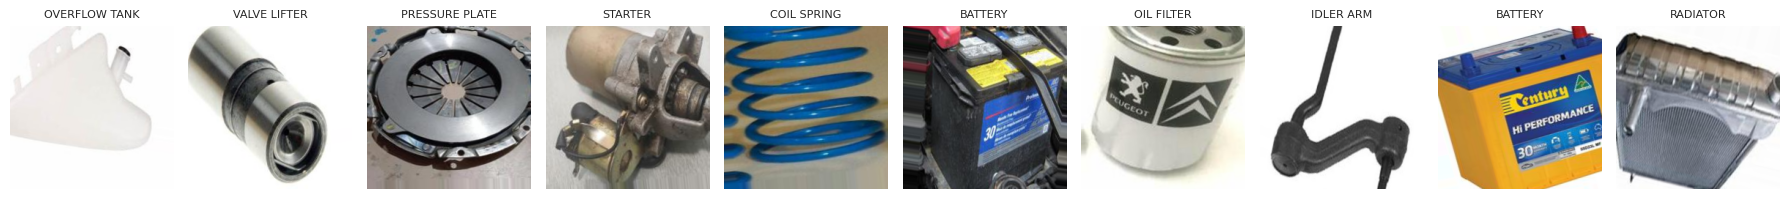

In [ ]:
# Get a batch of augmented images and labels
batch_images, batch_labels = next(train_generator)

# Display random images with labels
num_images = 10
random_indices = np.random.choice(batch_images.shape[0], num_images, replace=False)
random_images = batch_images[random_indices]
random_labels = batch_labels[random_indices]

# Class indices mapping (decode integer -> class name)
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# Display the random images with decoded labels
plt.figure(figsize=(18, 6))
for i in range(num_images):
    plt.subplot(1, num_images, i+1)
    plt.imshow(random_images[i])
    plt.title(f"{class_labels[np.argmax(random_labels[i])]}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pre-trained MobileNetV2 model without the top (classification) layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Number of classes in dataset (check train_generator.class_indices)
num_classes = len(train_generator.class_indices)

# Add new classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)  # helps prevent overfitting
predictions = Dense(num_classes, activation='softmax')(x)

# Create the transfer learning model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,620,978 (13.81 MB)

 Trainable params: 1,362,994 (5.20 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint("best_mobilenetv2_model.h5", monitor='val_loss', save_best_only=True, verbose=1)

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.2706 - loss: 3.0758
Epoch 1: val_loss improved from inf to 0.89629, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 147s 480ms/step - accuracy: 0.2713 - loss: 3.0728 - val_accuracy: 0.7960 - val_loss: 0.8963
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7179 - loss: 1.0665
Epoch 2: val_loss improved from 0.89629 to 0.57683, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 114s 415ms/step - accuracy: 0.7180 - loss: 1.0661 - val_accuracy: 0.8760 - val_loss: 0.5768
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.7959 - loss: 0.7367
Epoch 3: val_loss improved from 0.57683 to 0.51186, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 109s 397ms/step - accuracy: 0.7959 - loss: 0.7367 - val_accuracy: 0.8480 - val_loss: 0.5119
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8342 - loss: 0.6046
Epoch 4: val_loss improved from 0.51186 to 0.44433, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 110s 400ms/step - accuracy: 0.8342 - loss: 0.6046 - val_accuracy: 0.8800 - val_loss: 0.4443
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.8418 - loss: 0.5452
Epoch 5: val_loss improved from 0.44433 to 0.43153, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 108s 394ms/step - accuracy: 0.8418 - loss: 0.5452 - val_accuracy: 0.8880 - val_loss: 0.4315
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.8592 - loss: 0.4703
Epoch 6: val_loss improved from 0.43153 to 0.39485, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 109s 400ms/step - accuracy: 0.8592 - loss: 0.4703 - val_accuracy: 0.9000 - val_loss: 0.3948
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8644 - loss: 0.4553
Epoch 7: val_loss improved from 0.39485 to 0.37804, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 109s 396ms/step - accuracy: 0.8645 - loss: 0.4552 - val_accuracy: 0.9080 - val_loss: 0.3780
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8854 - loss: 0.3802
Epoch 8: val_loss did not improve from 0.37804
274/274 ━━━━━━━━━━━━━━━━━━━━ 109s 397ms/step - accuracy: 0.8854 - loss: 0.3802 - val_accuracy: 0.9000 - val_loss: 0.3930
Epoch 9/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8911 - loss: 0.3533
Epoch 9: val_loss improved from 0.37804 to 0.36999, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 110s 402ms/step - accuracy: 0.8911 - loss: 0.3534 - val_accuracy: 0.9080 - val_loss: 0.3700
Epoch 10/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9011 - loss: 0.3333
Epoch 10: val_loss improved from 0.36999 to 0.35431, saving model to best_mobilenetv2_model.h5


274/274 ━━━━━━━━━━━━━━━━━━━━ 111s 404ms/step - accuracy: 0.9011 - loss: 0.3333 - val_accuracy: 0.9120 - val_loss: 0.3543
Restoring model weights from the end of the best epoch: 10.


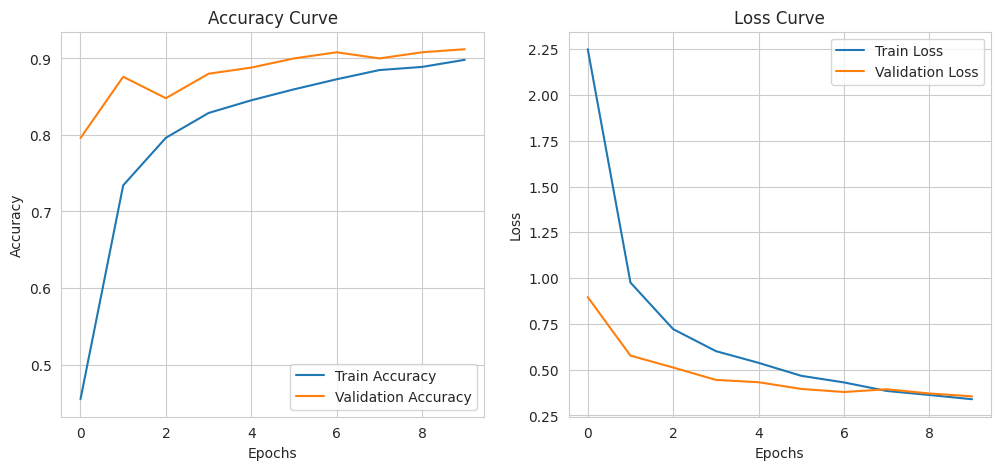

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Plot Accuracy and Loss Curves
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.show()

plot_history(history)

In [ ]:
# 2. Evaluate model on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9172 - loss: 0.2283

Test Accuracy: 0.9280
Test Loss: 0.2106


8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 662ms/step


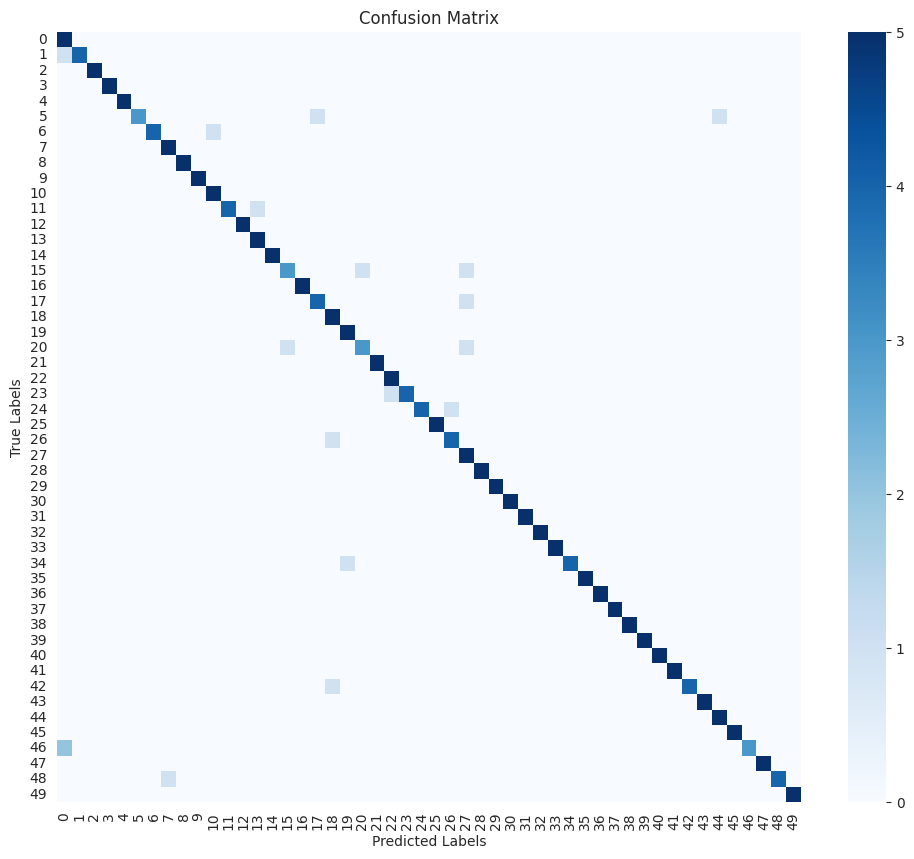

In [ ]:
# 3. Confusion Matrix & Classification Report
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
# Classification report
target_names = list(test_generator.class_indices.keys())
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


Classification Report:

                      precision    recall  f1-score   support

      AIR COMPRESSOR       0.62      1.00      0.77         5
          ALTERNATOR       1.00      0.80      0.89         5
             BATTERY       1.00      1.00      1.00         5
       BRAKE CALIPER       1.00      1.00      1.00         5
           BRAKE PAD       1.00      1.00      1.00         5
         BRAKE ROTOR       1.00      0.60      0.75         5
            CAMSHAFT       1.00      0.80      0.89         5
          CARBERATOR       0.83      1.00      0.91         5
        CLUTCH PLATE       1.00      1.00      1.00         5
         COIL SPRING       1.00      1.00      1.00         5
          CRANKSHAFT       0.83      1.00      0.91         5
       CYLINDER HEAD       1.00      0.80      0.89         5
         DISTRIBUTOR       1.00      1.00      1.00         5
        ENGINE BLOCK       0.83      1.00      0.91         5
        ENGINE VALVE       1.00      1.00   

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


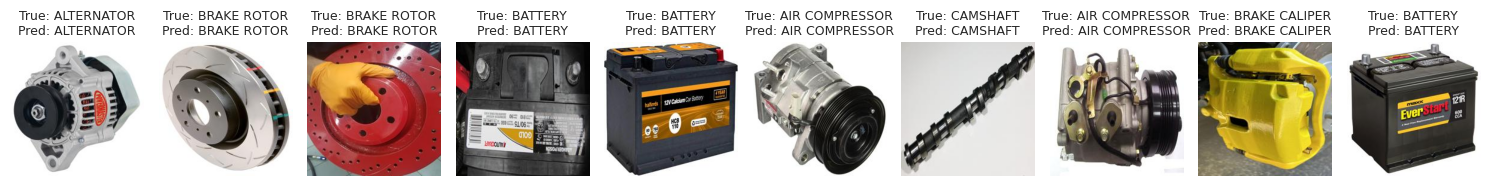

In [ ]:
# 4. Test on random sample images with actual vs predicted labels
num_images = 10
batch_images, batch_labels = next(test_generator)  # get a batch
random_indices = np.random.choice(batch_images.shape[0], num_images, replace=False)

plt.figure(figsize=(15,5))
for i, idx in enumerate(random_indices):
    img = batch_images[idx]
    true_label = np.argmax(batch_labels[idx])
    pred_label = np.argmax(model.predict(img[np.newaxis, ...]))

    plt.subplot(1, num_images, i+1)
    plt.imshow(img)
    plt.title(f"True: {target_names[true_label]}\nPred: {target_names[pred_label]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Save model in HDF5 (.h5) format
model.save("mobilenetv2_car_parts.h5")
print("Model saved as mobilenetv2_car_parts.h5")

Model saved as mobilenetv2_car_parts.h5
